 **Handwritten Digits Classification Using Multilayer Perceptron**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt

### Load the Dataset

In [2]:
# Load the MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.22MB/s]


In [3]:
len(train_dataset), len(test_dataset)

(60000, 10000)

In [4]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

data_iter = iter(train_loader)
images, labels = next(data_iter)

In [5]:
images.shape, labels.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

In [6]:
images[0].shape

torch.Size([1, 28, 28])

In [7]:
images[0].squeeze().shape

torch.Size([28, 28])

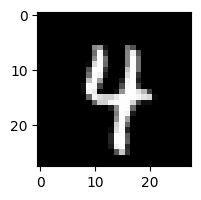

In [8]:
plt.figure(figsize=(2,2))
plt.imshow(images[4].squeeze(), cmap="gray")
plt.show()

In [9]:
labels[4]

tensor(4)

### Train a Fully Connected Neural Network (FCNN)

In [10]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

In [11]:
# Instantiate the model, define loss function and optimizer
model = DigitClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
epochs = 5
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()          # Zero the gradients
        outputs = model(images)        # Forward pass
        loss = criterion(outputs, labels) # Compute loss
        loss.backward()                # Backpropagate
        optimizer.step()               # Update weights

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")

Epoch [1/5], Loss: 0.3981
Epoch [2/5], Loss: 0.1892
Epoch [3/5], Loss: 0.1370
Epoch [4/5], Loss: 0.1120
Epoch [5/5], Loss: 0.0951


In [12]:
# Testing the model
model.eval()  # Switch to evaluation mode
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on the test set: {100 * correct / total:.2f}%')

Accuracy on the test set: 96.19%


### Classification Report & Confusion Matrix

In [13]:
# Testing the model
model.eval()  # Switch to evaluation mode

all_predicted = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        # Append labels and predictions to lists
        all_labels.extend(labels.numpy())
        all_predicted.extend(predicted.numpy())

In [14]:
len(all_predicted)

10000

In [15]:
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_predicted)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.96      0.97      1032
           3       0.92      0.98      0.95      1010
           4       0.88      0.99      0.93       982
           5       0.97      0.96      0.97       892
           6       0.97      0.97      0.97       958
           7       0.98      0.95      0.96      1028
           8       0.97      0.96      0.96       974
           9       0.99      0.88      0.93      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_predicted)
cm

array([[ 961,    0,    0,    1,    3,    2,    7,    2,    3,    1],
       [   0, 1119,    1,    3,    2,    2,    4,    1,    3,    0],
       [   3,    1,  990,   20,    5,    0,    3,    4,    6,    0],
       [   0,    0,    1,  994,    1,    5,    0,    4,    3,    2],
       [   0,    0,    2,    0,  974,    1,    4,    1,    0,    0],
       [   5,    0,    0,   13,    3,  858,    5,    0,    5,    3],
       [   4,    1,    0,    1,   17,    4,  926,    0,    5,    0],
       [   0,    4,    8,   27,    7,    0,    1,  974,    3,    4],
       [   4,    0,    2,   11,    9,    5,    5,    3,  932,    3],
       [   3,    2,    0,    9,   85,    9,    1,    8,    1,  891]])

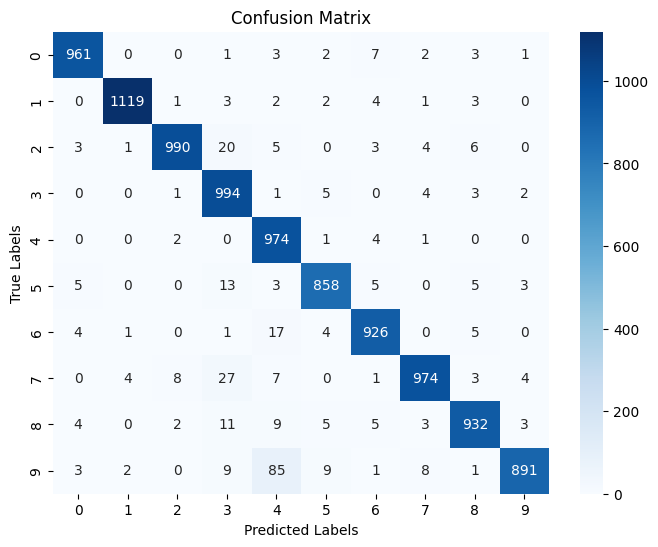

In [17]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(len(cm)), yticklabels=range(len(cm)))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()